In [4]:
import open3d as o3d
import numpy as np
import os

## Loading and Preprocessing

In [5]:
# Load point cloud
workspace_dir = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/"
dense_dir = os.path.join(workspace_dir,"dense")
pcd = o3d.io.read_point_cloud(os.path.join(dense_dir,"fused.ply"))
print(pcd)
print("Total points:", np.asarray(pcd.points).shape[0])

# Downsampling
voxel_size = 0.08  # tuned for your dataset
pcd_down = pcd.voxel_down_sample(voxel_size)
print("Downsampled points:", np.asarray(pcd_down.points).shape[0])

# Remove Statistical Outliers
pcd_clean, ind = pcd_down.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print("After cleaning:", len(pcd_clean.points))

PointCloud with 3441841 points.
Total points: 3441841
Downsampled points: 83224
After cleaning: 83033


In [6]:
# Cropping the Main Building Region only
bbox = o3d.geometry.AxisAlignedBoundingBox( min_bound=[-5, -3, -2],max_bound=[12, 4, 14])
pcd_building = pcd_clean.crop(bbox)
print("After cropping:", len(pcd_building.points))

pcd_building.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1,max_nn=30))
pcd_building.normalize_normals()
# Convert to NumPy
points = np.asarray(pcd_building.points)

After cropping: 42198


## RANSAC for plane detection

In [7]:
def fit_plane(p1, p2, p3):
    v1 = p2 - p1
    v2 = p3 - p1

    normal = np.cross(v1, v2)
    if np.linalg.norm(normal) == 0:
        return None

    normal = normal / np.linalg.norm(normal)
    d = -np.dot(normal, p1)

    return (*normal, d)


def point_to_plane_distance(points, plane):
    a, b, c, d = plane
    return np.abs(a*points[:,0] + b*points[:,1] + c*points[:,2] + d)

In [8]:
def extract_dominant_planes(points,
                           num_planes=15,
                           distance_threshold=0.05,
                           min_inliers=400,
                           num_iterations=500):

    # Keep track of original indices
    remaining_points = points.copy()
    remaining_indices = np.arange(len(points))

    all_planes = []
    all_inliers = []

    for _ in range(num_planes):

        best_plane = None
        best_inliers = []

        n_points = remaining_points.shape[0]
        if n_points < 3:
            break

        for _ in range(num_iterations):
            idx = np.random.choice(n_points, 3, replace=False)
            p1, p2, p3 = remaining_points[idx]

            plane = fit_plane(p1, p2, p3)
            if plane is None:
                continue

            distances = point_to_plane_distance(remaining_points, plane)
            inliers = np.where(distances < distance_threshold)[0]

            if len(inliers) < min_inliers:
                continue

            # Planarity check
            pts = remaining_points[inliers]
            centroid = np.mean(pts, axis=0)
            cov = np.cov(pts - centroid, rowvar=False)

            eigvals = np.sort(np.linalg.eigvals(cov))
            planarity = eigvals[0] / (eigvals.sum() + 1e-6)

            if planarity > 0.02:
                continue

            if len(inliers) > len(best_inliers):
                best_plane = plane
                best_inliers = inliers

        if best_plane is None:
            break

        all_planes.append(best_plane)

        # 🔥 FIX: map to original indices
        global_inliers = remaining_indices[best_inliers]
        all_inliers.append(global_inliers)

        # Remove inliers
        mask = np.ones(n_points, dtype=bool)
        mask[best_inliers] = False

        remaining_points = remaining_points[mask]
        remaining_indices = remaining_indices[mask]

    return all_planes, all_inliers

In [9]:
planes, plane_inliers = extract_dominant_planes(
    points,
    num_planes=6,
    distance_threshold=0.05,
    min_inliers=250,
    num_iterations=500
)

print("Detected planes:", len(planes))

Detected planes: 6


In [10]:
def visualize_only_planes(points, inliers_list):
    import open3d as o3d

    all_indices = np.concatenate(inliers_list)
    all_indices = np.unique(all_indices)

    pcd_planes = o3d.geometry.PointCloud()
    pcd_planes.points = o3d.utility.Vector3dVector(points[all_indices])

    colors = np.zeros((len(all_indices), 3))

    index_map = {idx: i for i, idx in enumerate(all_indices)}

    for inliers in inliers_list:
        color = np.random.rand(3)

        for idx in inliers:
            if idx in index_map:
                colors[index_map[idx]] = color

    pcd_planes.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([pcd_planes])

In [15]:
def visualize_only_planes(points, inliers_list):
    import open3d as o3d
    import numpy as np

    # ---- curated palette ----
    # ---- curated palette ----
    palette = [
        [0.121, 0.466, 0.705],  # blue
        # [1.000, 0.498, 0.054],  # orange
        # [0.172, 0.627, 0.172],  # green
        # [0.608, 0.733, 0.596],
        [0.420, 0.557, 0.137],
        # [0.839, 0.153, 0.157],  # red
        [0.580, 0.404, 0.741],  # purple
        [0.549, 0.337, 0.294],  # brown
        [0.890, 0.467, 0.761],  # pink
        [0.498, 0.498, 0.498],  # gray
        [0.737, 0.741, 0.133],  # olive
        [0.090, 0.745, 0.811],  # cyan
        [0.650, 0.850, 0.415],  # light green
        [0.984, 0.705, 0.682],  # light red
        [0.702, 0.871, 0.984],  # light blue
        [0.992, 0.851, 0.184],  # yellow
        [0.792, 0.698, 0.839],  # lavender
    ]

    # ---- collect all plane points ----
    all_indices = np.concatenate(inliers_list)
    all_indices = np.unique(all_indices)

    pcd_planes = o3d.geometry.PointCloud()
    pcd_planes.points = o3d.utility.Vector3dVector(points[all_indices])

    colors = np.zeros((len(all_indices), 3))
    index_map = {idx: i for i, idx in enumerate(all_indices)}

    # ---- assign colors deterministically ----
    for i, inliers in enumerate(inliers_list):
        color = palette[i % len(palette)]

        for idx in inliers:
            if idx in index_map:
                colors[index_map[idx]] = color

    pcd_planes.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([pcd_planes])

In [32]:
visualize_only_planes(points, plane_inliers)

In [17]:
for i, inliers in enumerate(plane_inliers):
    print(f"Plane {i}: {len(inliers)} points")

Plane 0: 7187 points
Plane 1: 5601 points
Plane 2: 4218 points
Plane 3: 2373 points
Plane 4: 1685 points
Plane 5: 2206 points


## Plane Refinement

In [18]:
def refine_plane(points):
    centroid = np.mean(points, axis=0)
    cov = np.cov(points - centroid, rowvar=False)

    _, _, vh = np.linalg.svd(cov)
    normal = vh[-1]

    d = -np.dot(normal, centroid)
    return (*normal, d)

In [19]:
refined_planes = [refine_plane(points[inl]) for inl in plane_inliers]

In [20]:
def filter_by_normal(planes, inliers, threshold=0.3):
    filtered_planes = []
    filtered_inliers = []

    for p, inl in zip(planes, inliers):
        normal = np.array(p[:3])

        # remove near-random orientations (vegetation)
        if abs(normal[2]) < threshold:  # adjust axis depending on orientation
            filtered_planes.append(p)
            filtered_inliers.append(inl)

    return filtered_planes, filtered_inliers

In [21]:
filtered_planes, filtered_inliers = filter_by_normal(
    planes,
    plane_inliers,
    threshold=0.7
)

In [22]:
visualize_only_planes(points, filtered_inliers)

In [46]:
def filter_planes_robust(planes, inliers, min_size=300):
    filtered_planes = []
    filtered_inliers = []

    for p, inl in zip(planes, inliers):
        if len(inl) < min_size:
            continue

        filtered_planes.append(p)
        filtered_inliers.append(inl)

    return filtered_planes, filtered_inliers

In [47]:
filtered_planes, filtered_inliers = filter_planes_robust(
    planes,
    plane_inliers,
    min_size=300
)

In [60]:
visualize_only_planes(points, filtered_inliers)

## Mesh Generation

In [12]:
def visualize_only_planes(points, inliers_list):
    import open3d as o3d
    import numpy as np

    # ---- curated palette ----
    palette = [
        [0.121, 0.466, 0.705],  # blue
        # [1.000, 0.498, 0.054],  # orange
        # [0.172, 0.627, 0.172],  # green
        # [0.608, 0.733, 0.596],
        [0.420, 0.557, 0.137],
        # [0.839, 0.153, 0.157],  # red
        [0.580, 0.404, 0.741],  # purple
        [0.549, 0.337, 0.294],  # brown
        [0.890, 0.467, 0.761],  # pink
        [0.498, 0.498, 0.498],  # gray
        [0.737, 0.741, 0.133],  # olive
        [0.090, 0.745, 0.811],  # cyan
        [0.650, 0.850, 0.415],  # light green
        [0.984, 0.705, 0.682],  # light red
        [0.702, 0.871, 0.984],  # light blue
        [0.992, 0.851, 0.184],  # yellow
        [0.792, 0.698, 0.839],  # lavender
    ]

    # ---- collect all plane points ----
    all_indices = np.concatenate(inliers_list)
    all_indices = np.unique(all_indices)

    pcd_planes = o3d.geometry.PointCloud()
    pcd_planes.points = o3d.utility.Vector3dVector(points[all_indices])

    colors = np.zeros((len(all_indices), 3))
    index_map = {idx: i for i, idx in enumerate(all_indices)}

    # ---- assign colors deterministically ----
    for i, inliers in enumerate(inliers_list):
        color = palette[i % len(palette)]

        for idx in inliers:
            if idx in index_map:
                colors[index_map[idx]] = color

    pcd_planes.colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries([pcd_planes])

In [24]:
import open3d as o3d
import numpy as np

def create_mesh_alpha_shape(points, inliers, alpha=0.1):

    pts = points[inliers]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.estimate_normals()

    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
        pcd, alpha
    )

    mesh.compute_vertex_normals()
    return mesh

In [59]:
def create_mesh_bpa(points, inliers):

    pts = points[inliers]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)

    pcd.estimate_normals()

    radii = [0.05, 0.1, 0.2]

    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd,
        o3d.utility.DoubleVector(radii)
    )

    return mesh

In [25]:
palette = [
    [0.121, 0.466, 0.705],  # blue
    # [1.000, 0.498, 0.054],  # orange
    # [0.172, 0.627, 0.172],  # green
    # [0.608, 0.733, 0.596],
    [0.420, 0.557, 0.137],
    # [0.839, 0.153, 0.157],  # red
    [0.580, 0.404, 0.741],  # purple
    [0.549, 0.337, 0.294],  # brown
    [0.890, 0.467, 0.761],  # pink
    [0.498, 0.498, 0.498],  # gray
    [0.737, 0.741, 0.133],  # olive
    [0.090, 0.745, 0.811],  # cyan
    [0.650, 0.850, 0.415],  # light green
    [0.984, 0.705, 0.682],  # light red
    [0.702, 0.871, 0.984],  # light blue
    [0.992, 0.851, 0.184],  # yellow
    [0.792, 0.698, 0.839],  # lavender
]

In [62]:
meshes = []

# Optional but recommended: sort planes by size
plane_data = sorted(
    zip(planes, plane_inliers),
    key=lambda x: len(x[1]),
    reverse=True
)

for i, (plane, inliers) in enumerate(plane_data):

    if len(inliers) < 300:
        continue

    mesh = create_mesh_alpha_shape(points, inliers, alpha=0.2)

    # assign color from palette
    color = palette[i % len(palette)]
    mesh.paint_uniform_color(color)

    meshes.append(mesh)

o3d.visualization.draw_geometries(meshes)

## Quanitative Analysis

In [28]:
import numpy as np

def compute_plane_errors(points, planes, plane_inliers):
    all_errors = []
    plane_errors = []

    for plane, inliers in zip(planes, plane_inliers):
        a, b, c, d = plane

        pts = points[inliers]

        # normalize normal
        norm = np.sqrt(a*a + b*b + c*c)

        distances = np.abs(
            (pts[:, 0]*a + pts[:, 1]*b + pts[:, 2]*c + d)
        ) / norm

        plane_errors.append(distances)
        all_errors.extend(distances)

    return plane_errors, np.array(all_errors)

In [29]:
plane_errors, all_errors = compute_plane_errors(
    points,
    planes,
    plane_inliers
)

In [54]:
import matplotlib.pyplot as plt

def plot_error_histogram(all_errors, save_path = None):

    plt.figure(figsize=(10,4))
    plt.hist(all_errors, bins=250)
    plt.xlabel("Point-to-plane distance")
    plt.ylabel("Frequency")
    plt.title("Plane Fitting Error Distribution")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi = 300)

    plt.show()

Overall Mean Error: 0.019976661447154355
Overall Std Dev: 0.014122153810284683


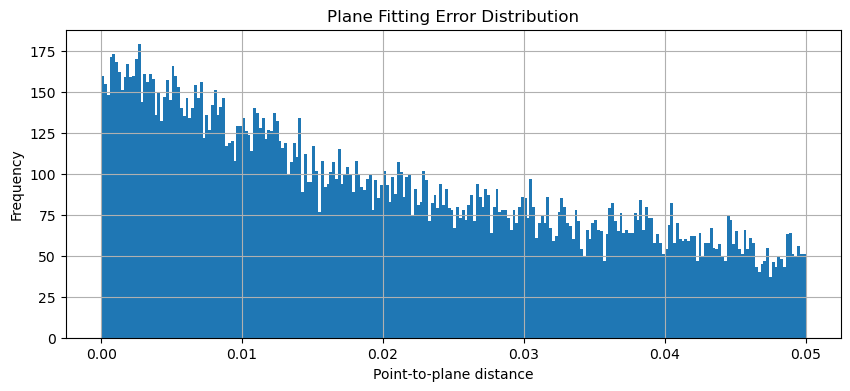

In [55]:
print("Overall Mean Error:", np.mean(all_errors))
print("Overall Std Dev:", np.std(all_errors))

image_save_dir = '/Users/arjunmallick/1. IISc/Sem 2/2. Computer Vision (CV)/3. Assignments/Assignment 4/Report'
image_name = 'dense_error_all.png'
image_save_path = os.path.join(image_save_dir, image_name)

plot_error_histogram(all_errors, image_save_path)

## Per-Plane Statistics

In [41]:
def print_plane_stats(plane_errors):

    for i, errors in enumerate(plane_errors):
        print(f"Plane {i}:")
        print(f"  Points: {len(errors)}")
        print(f"  Mean error: {np.mean(errors):.4f}")
        print(f"  Median error: {np.median(errors):.4f}")
        print(f"  Max error: {np.max(errors):.4f}")
        print("")

In [42]:
print_plane_stats(plane_errors)

Plane 0:
  Points: 7187
  Mean error: 0.0208
  Median error: 0.0196
  Max error: 0.0500

Plane 1:
  Points: 5601
  Mean error: 0.0128
  Median error: 0.0087
  Max error: 0.0499

Plane 2:
  Points: 4218
  Mean error: 0.0231
  Median error: 0.0219
  Max error: 0.0500

Plane 3:
  Points: 2373
  Mean error: 0.0247
  Median error: 0.0245
  Max error: 0.0500

Plane 4:
  Points: 1685
  Mean error: 0.0238
  Median error: 0.0227
  Max error: 0.0500

Plane 5:
  Points: 2206
  Mean error: 0.0217
  Median error: 0.0202
  Max error: 0.0500



In [56]:
def plot_per_plane_histograms(plane_errors, save_dir = None):

    for i, errors in enumerate(plane_errors):
        plt.figure()
        plt.hist(errors, bins=100)
        plt.title(f"Plane {i} Error Distribution")
        plt.xlabel("Distance")
        plt.ylabel("Frequency")
        if save_dir:
            image_name = f"dense_plane{i}.png"
            image_path = os.path.join(save_dir,image_name)
            plt.savefig(image_path,dpi = 300)
        plt.show()

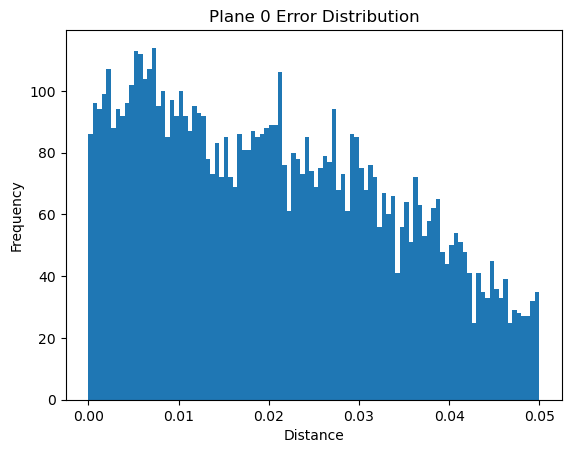

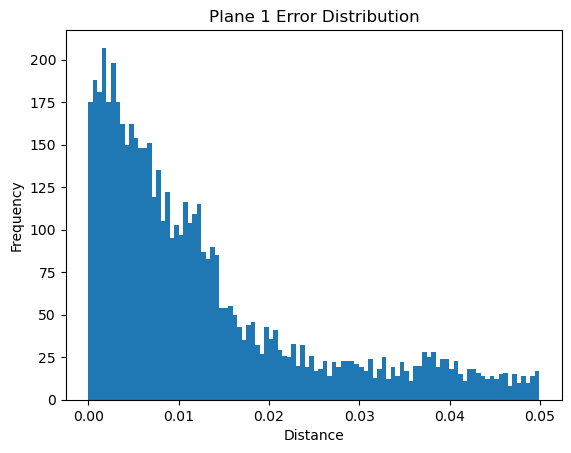

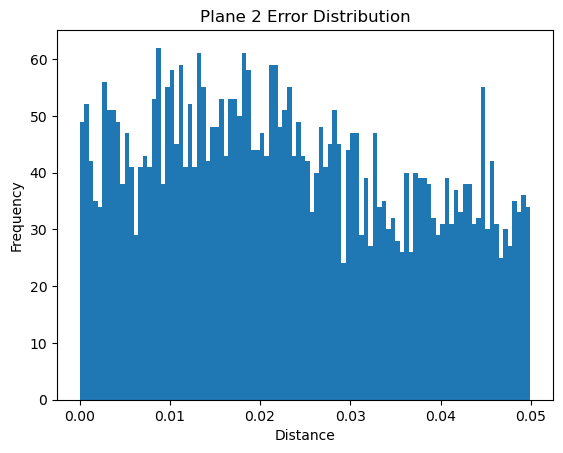

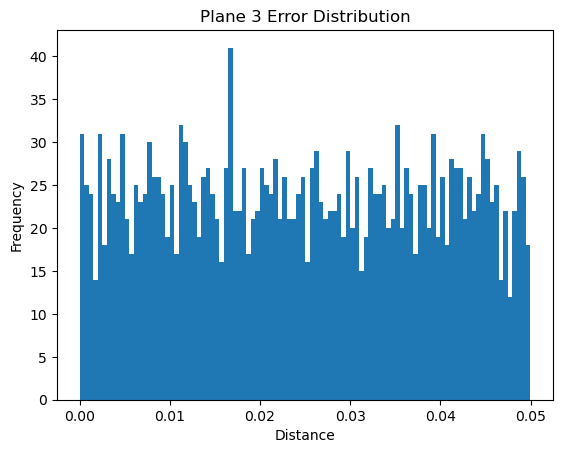

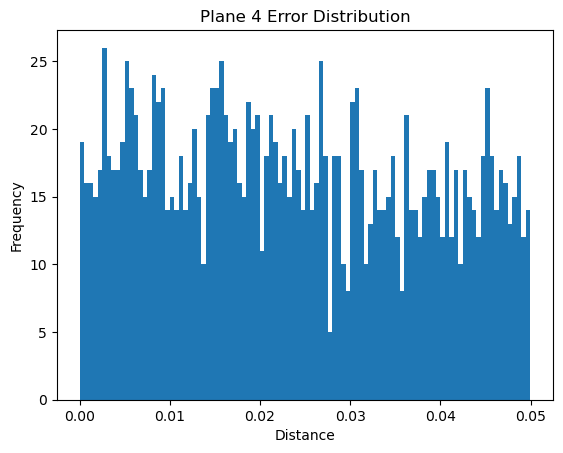

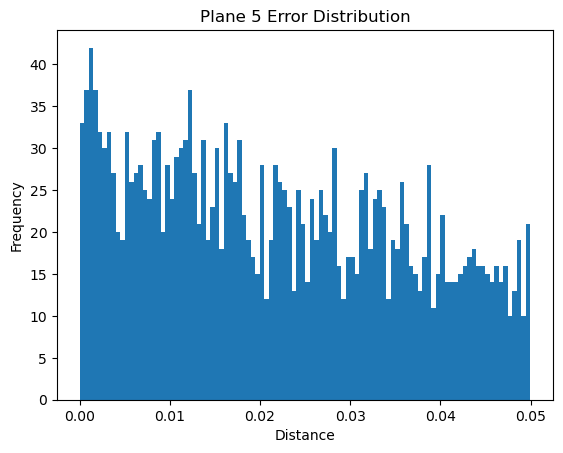

In [57]:
image_save_dir = '/Users/arjunmallick/1. IISc/Sem 2/2. Computer Vision (CV)/3. Assignments/Assignment 4/Report'
plot_per_plane_histograms(plane_errors, image_save_dir)